**TASK 1**

In [6]:
# 1. Import Libraries
import numpy as np
print(np. __version__) # Make sure your numpy version is 2.1.3
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical


2.0.2


In [7]:
import tensorflow as tf


**TASK 2**

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


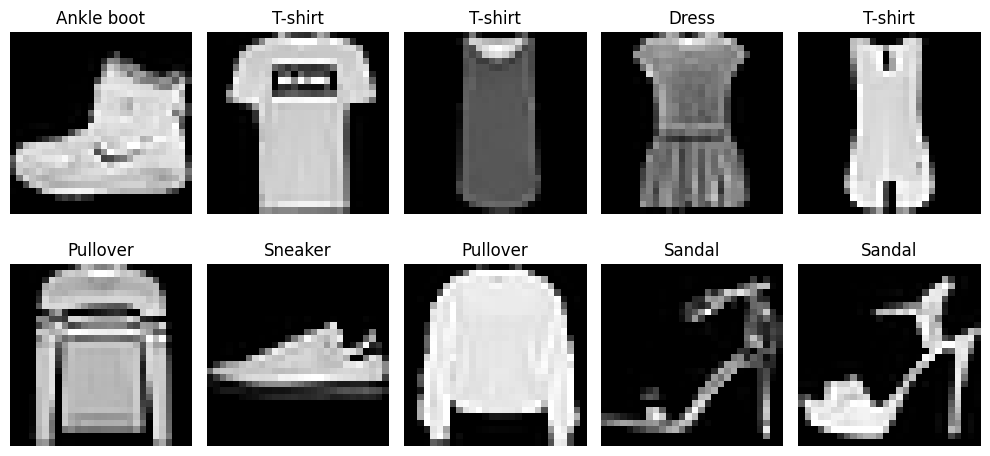

In [8]:
# 2. Load and Preprocess Data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
# 2.1 Visualize Data
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()
# 2.2. Image preprocessing
# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape to include channel dimension
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode the labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


**Task 3: Build a CNN Model**

In [9]:
# 3. Build the CNN Model

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])


**TASK 4: Compile the Model**

In [10]:
# 4. Compile your model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

**TASK 5: Train the CNN Model**

In [11]:
# 5. Train the Model
history = model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.7318 - loss: 0.7706 - val_accuracy: 0.8682 - val_loss: 0.3643
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - accuracy: 0.8694 - loss: 0.3556 - val_accuracy: 0.8885 - val_loss: 0.3068
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 55ms/step - accuracy: 0.8887 - loss: 0.2994 - val_accuracy: 0.8869 - val_loss: 0.2986
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.8986 - loss: 0.2741 - val_accuracy: 0.8998 - val_loss: 0.2684
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 58ms/step - accuracy: 0.9090 - loss: 0.2453 - val_accuracy: 0.9062 - val_loss: 0.2567
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 79s 54ms/step - accuracy: 0.9155 - loss: 0.2265 - val_accuracy: 0.9082 - val_loss: 0.2496
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9245 - loss: 0.2022 - val_accuracy: 0.9075 - val_loss: 0.2549
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9283 - loss: 0.1905 - 

**Task 6: Evaluate on Test Set**

In [12]:
# 6. Evaluate on Test Set
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0) # we can use evaluate() to get accuracy
print(f"Test Accuracy: {test_acc:.4f}")

y_pred = model.predict(x_test) # or we can make predictions first
y_pred_classes = np.argmax(y_pred, axis=1)
print(confusion_matrix(y_test, y_pred_classes)) # print confusion_matrix
print(classification_report(y_test, y_pred_classes, target_names=class_names)) # print classification report


Test Accuracy: 0.9121
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
[[846   0  26  13   4   1 101   0   8   1]
 [  3 977   1  15   1   0   1   0   2   0]
 [  9   0 882   7  44   0  57   0   1   0]
 [ 13   2  12 903  32   0  36   0   2   0]
 [  1   0  42  18 896   0  42   0   1   0]
 [  0   0   0   0   0 981   0  10   1   8]
 [ 87   1  73  22  85   0 712   0  20   0]
 [  0   0   0   0   0   8   0 972   0  20]
 [  1   0   3   3   2   1   2   2 986   0]
 [  1   0   0   0   0   5   0  28   0 966]]
              precision    recall  f1-score   support

     T-shirt       0.88      0.85      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.85      0.88      0.87      1000
       Dress       0.92      0.90      0.91      1000
        Coat       0.84      0.90      0.87      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.75      0.71      0.73      1000
     Sneaker       0.96      0.97      0.97      1000
         Bag      

**Task 7**

**7.1 What is the purpose of convolution in a CNN?**

Convolution helps the model to detect patterns in images, like edges, corners or textures. so, It works by sliding small filters over the image and highlighting important features. Instead of looking at every pixel one by one, convolution lets the model focus on useful parts and build a better understanding of what’s in the image.

**7.2 What is padding and why do we need it?**

Padding means adding extra pixels (like usually adding zeros) around the border of an image. We use it to make sure that the size of the output image after convolution doesn't shrink too much. Without padding, the image gets smaller every time we apply a filter and we may lose important details near the edges. so, Padding helps to keep the original size and allows the model to learn from the corners and edges as well.

**7.3 What does a pooling layer do in a CNN?**

Generally, Pooling helps to make the image smaller while keeping the important information. It does this by picking the most important value like the highest number from small regions of the image. so, this makes the model faster, uses less memory and also helps it to focus on the main features without getting confused by tiny details or noise.